In [2]:
import json, os
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
from matplotlib import pyplot as plt
import networkx as nx
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib

# import lts calculation functions
from lts_functions import (biking_permitted, is_separated_path, is_bike_lane, parking_present,
                           bike_lane_analysis_no_parking, bike_lane_analysis_with_parking, mixed_traffic)

# ## Extract OSM tags to use in download


f = open("victoriaosm.osm") # a larger bounding box for the city
data = json.load(f)

# +
# make a dataframe of tags
dfs = []

for element in data['elements']:
    if element['type'] != 'way':
        continue
    df = pd.DataFrame.from_dict(element['tags'], orient = 'index')
    dfs.append(df)
# -

tags_df = pd.concat(dfs).reset_index()
tags_df.columns = ["tag", "tagvalue"]

tag_value_counts = tags_df.value_counts().reset_index() # count all the unique tag and value combinations
tag_counts = tags_df['tag'].value_counts().reset_index() # count all the unique tags

print(tag_counts)

# explore the tags that start with 'cycleway'
tag_counts[tag_counts['tag'].str.contains('cycleway')]

way_tags = list(tag_counts['tag']) # all unique tags from the OSM Toronto download

# add the above list to the global osmnx settings
ox.settings.useful_tags_way += way_tags
ox.settings.osm_xml_way_tags = way_tags


                      tag  count
0                 highway  18306
1                 surface   8819
2                    name   6221
3                sidewalk   4609
4                maxspeed   3915
..                    ...    ...
253  payment:credit_cards      1
254   payment:debit_cards      1
255  parking:left:maxstay      1
256         class:bicycle      1
257             sac_scale      1

[258 rows x 2 columns]


In [ ]:
City = 
State = 
City_osm_file = 
Country = 

In [3]:
way_tags

['highway',
 'surface',
 'name',
 'sidewalk',
 'maxspeed',
 'lanes',
 'service',
 'bicycle',
 'oneway',
 'source',
 'barrier',
 'footway',
 'source:maxspeed',
 'foot',
 'crossing',
 'cycleway',
 'crossing:markings',
 'access',
 'lit',
 'cycleway:right',
 'cycleway:left',
 'cycleway:both',
 'maxspeed:type',
 'lane_markings',
 'lanes:backward',
 'lanes:forward',
 'segregated',
 'sidewalk:both',
 'width',
 'crossing:island',
 'layer',
 'tactile_paving',
 'bridge',
 'ref',
 'NHS',
 'motor_vehicle',
 'incline',
 'fence_type',
 'parking:both',
 'comment',
 'kerb',
 'covered',
 'golf_cart',
 'handrail',
 'railway',
 'ramp',
 'sidewalk:right',
 'expressway',
 'cycleway:both:lane',
 'tunnel',
 'busway',
 'horse',
 'junction',
 'turn:lanes:forward',
 'sidewalk:left',
 'smoothness',
 'turn:lanes:backward',
 'area',
 'step_count',
 'button_operated',
 'hazard',
 'oneway:bicycle',
 'parking:both:orientation',
 'informal',
 'parking:left',
 'level',
 'parking:right',
 'crossing:signals',
 'maxheight

loading saved graph


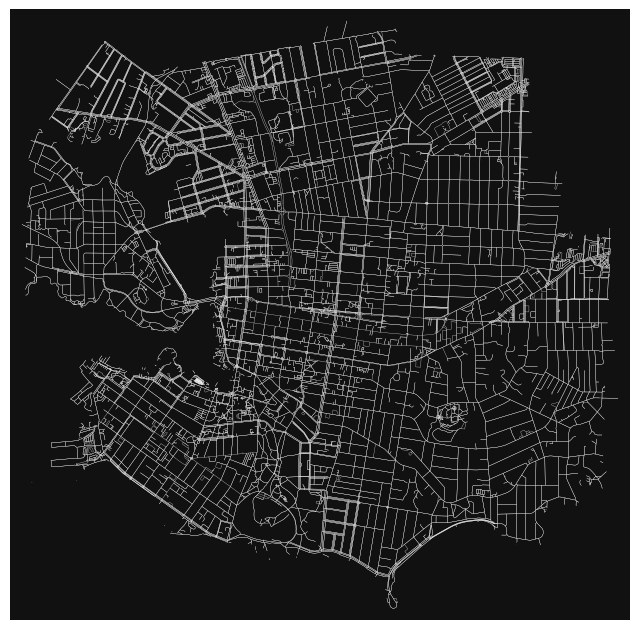

In [4]:
# ### Download data

# create a filter to download selected data
# this filter is based on osmfilter = ox.downloader._get_osm_filter("bike")
# keeping the footway and construction tags
osmfilter = '["highway"]["area"!~"yes"]["access"!~"private"]["highway"!~"abandoned|bus_guideway|corridor|elevator|escalator|motor|planned|platform|proposed|raceway|steps"]["bicycle"!~"no"]["service"!~"private"]'

city = "Victoria"
province = "British Columbia"

# check if data has already been downloaded; if not, download
filepath = "data/%s.graphml" %city
if os.path.exists(filepath):
    # load graph
    print("loading saved graph")
    G = ox.load_graphml(filepath)
else:
    # download data - this can be slow
    print("downloading data")
    G = ox.graph_from_place(
        "%s, %s, Canada" %(city, province),
        retain_all=True,
        truncate_by_edge=True,
        simplify=False,
        custom_filter=osmfilter,
    )
    # save graph
    print("saving graph")
    ox.save_graphml(G, filepath)

# plot downloaded graph - this is slow for a large area
fig, ax = ox.plot_graph(G, node_size=0, edge_color="w", edge_linewidth=0.2)


In [5]:
# ## Analyze LTS
#
# Start with is biking allowed, get edges where biking is not *not* allowed.

# convert graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

print(gdf_edges.shape)
gdf_allowed, gdf_not_allowed = biking_permitted(gdf_edges)
print(gdf_allowed.shape)
print(gdf_not_allowed.shape)

# check for separated path
separated_edges, unseparated_edges = is_separated_path(gdf_allowed)
# assign separated ways lts = 1
separated_edges['lts'] = 1
print(separated_edges.shape)
print(unseparated_edges.shape)

to_analyze, no_lane = is_bike_lane(unseparated_edges)
print(to_analyze.shape)
print(no_lane.shape)

parking_detected, parking_not_detected = parking_present(to_analyze)
print(parking_detected.shape)
print(parking_not_detected.shape)

parking_lts = bike_lane_analysis_with_parking(parking_detected)

no_parking_lts = bike_lane_analysis_no_parking(parking_not_detected)

# Next, go to the last step - mixed traffic

lts_no_lane = mixed_traffic(no_lane)

# final components: lts_no_lane, parking_lts, no_parking_lts, separated_edges
# these should all add up to gdf_allowed
print(gdf_allowed.shape)
lts_no_lane.shape[0] + parking_lts.shape[0] + no_parking_lts.shape[0] + separated_edges.shape[0]

gdf_not_allowed['lts'] = 0

all_lts = pd.concat([separated_edges, parking_lts, no_parking_lts, lts_no_lane, gdf_not_allowed])


(58303, 146)
(47986, 147)
(10317, 147)
(18978, 148)
(29008, 146)
(1572, 146)
(27436, 146)
(46, 146)
(1526, 146)
(47986, 147)


In [6]:
# decision rule glossary
# these are from Bike Ottawa's stressmodel code
rule_message_dict = {'p2':'Cycling not permitted due to bicycle=\'no\' tag.',
                     'p6':'Cycling not permitted due to access=\'no\' tag.',
                     'p3':'Cycling not permitted due to highway=\'motorway\' tag.',
                     'p4':'Cycling not permitted due to highway=\'motorway_link\' tag.',
                     'p7':'Cycling not permitted due to highway=\'proposed\' tag.',
                     'p5':'Cycling not permitted. When footway="sidewalk" is present, there must be a bicycle="yes" when the highway is "footway" or "path".',
                     's3':'This way is a separated path because highway=\'cycleway\'.',
                     's1':'This way is a separated path because highway=\'path\'.',
                     's2':'This way is a separated path because highway=\'footway\' but it is not a crossing.',
                     's7':'This way is a separated path because cycleway* is defined as \'track\'.',
                     's8':'This way is a separated path because cycleway* is defined as \'opposite_track\'.',
                     'b1':'LTS is 1 because there is parking present, the maxspeed is less than or equal to 40, highway="residential", and there are 2 lanes or less.',
                     'b2':'Increasing LTS to 3 because there are 3 or more lanes and parking present.',
                     'b3':'Increasing LTS to 3 because the bike lane width is less than 4.1m and parking present.',
                     'b4':'Increasing LTS to 2 because the bike lane width is less than 4.25m and parking present.',
                     'b5':'Increasing LTS to 2 because the bike lane width is less than 4.5m, maxspeed is less than 40 on a residential street and parking present.',
                     'b6':'Increasing LTS to 2 because the maxspeed is between 41-50 km/h and parking present.',
                     'b7':'Increasing LTS to 3 because the maxspeed is between 51-54 km/h and parking present.',
                     'b8':'Increasing LTS to 4 because the maxspeed is over 55 km/h and parking present.',
                     'b9':'Increasing LTS to 3 because highway is not \'residential\'.',
                     'c1':'LTS is 1 because there is no parking, maxspeed is less than or equal to 50, highway=\'residential\', and there are 2 lanes or less.',
                     'c3':'Increasing LTS to 3 because there are 3 or more lanes and no parking.',
                     'c4':'Increasing LTS to 2 because the bike lane width is less than 1.7 metres and no parking.',
                     'c5':'Increasing LTS to 3 because the maxspeed is between 51-64 km/h and no parking.',
                     'c6':'Increasing LTS to 4 because the maxspeed is over 65 km/h and no parking.',
                     'c7':'Increasing LTS to 3 because highway with bike lane is not \'residential\' and no parking.',
                     'm17':'Setting LTS to 1 because motor_vehicle=\'no\'.',
                     'm13':'Setting LTS to 1 because highway=\'pedestrian\'.',
                     'm14':'Setting LTS to 2 because highway=\'footway\' and footway=\'crossing\'.',
                     'm2':'Setting LTS to 2 because highway=\'service\' and service=\'alley\'.',
                     'm15':'Setting LTS to 2 because highway=\'track\'.',
                     'm3':'Setting LTS to 2 because maxspeed is 50 km/h or less and service is \'parking_aisle\'.',
                     'm4':'Setting LTS to 2 because maxspeed is 50 km/h or less and service is \'driveway\'.',
                     'm16':'Setting LTS to 2 because maxspeed is less than 35 km/h and highway=\'service\'.',
                     'm5':'Setting LTS to 2 because maxspeed is up to 40 km/h, 3 or fewer lanes and highway=\'residential\'.',
                     'm6':'Setting LTS to 3 because maxspeed is up to 40 km/h and 3 or fewer lanes on non-residential highway.',
                     'm7':'Setting LTS to 3 because maxspeed is up to 40 km/h and 4 or 5 lanes.',
                     'm8':'Setting LTS to 4 because maxspeed is up to 40 km/h and the number of lanes is greater than 5.',
                     'm9':'Setting LTS to 2 because maxspeed is up to 50 km/h and lanes are 2 or less and highway=\'residential\'.',
                     'm10':'Setting LTS to 3 because maxspeed is up to 50 km/h and lanes are 3 or less on non-residential highway.',
                     'm11':'Setting LTS to 4 because the number of lanes is greater than 3.',
                     'm12':'Setting LTS to 4 because maxspeed is greater than 50 km/h.'}


In [7]:
simplified_message_dict = {'p2':r'bicycle $=$ "no"',
                     'p6':r'access $=$ "no"',
                     'p3':r'highway $=$ "motorway"',
                     'p4':r'highway $=$ "motorway_link"',
                     'p7':r'highway $=$ "proposed"',
                     'p5':r'footway $=$ "sidewalk", bicycle$\neq$"yes"',
                     's3':r'highway $=$ "cycleway"',
                     's1':r'highway $=$" path"',
                     's2':r'separated, highway $=$" footway", not a crossing',
                     's7':r'cycleway* $=$ "track"',
                     's8':r'cycleway* $=$ "opposite_track"',
                     'b1':r'bike lane w/ parking, $\leq$ 40 km/h, highway $=$ "residential", $\leq$ 2 lanes',
                     'b2':r'bike lane w/ parking, 3 or more lanes',
                     'b3':r'bike lane width $<$ 4.1m, parking',
                     'b4':r'bike lane width $<$ 4.25m, parking',
                     'b5':r'bike lane width $<$ 4.5m, $\leq$ 40 km/h, residential, parking',
                     'b6':r'bike lane w/ parking, speed 41-50 km/h',
                     'b7':r'bike lane w/ parking, speed 51-54 km/h',
                     'b8':r'bike lane w/ parking, speed $>$ 55 km/h',
                     'b9':r'bike lane w/ parking, highway $\neq$ "residential"',
                     'c1':r'bike lane no parking, $\leq$ 50 km/h, highway $=$ "residential", $\leq$ 2 lanes',
                     'c3':r'bike lane no parking, $\leq$ 65 km/h, $\geq$ 3 lanes',
                     'c4':r'bike lane width $<$ 1.7m, no parking',
                     'c5':r'bike lane no parking, speed 51-64 km/h',
                     'c6':r'bike lane no parking, speed $>$ 65 km/h',
                     'c7':r'bike lane no parking, highway $\neq$ "residential"',
                     'm17':r'mixed traffic, motor_vehicle $=$ "no"',
                     'm13':r'mixed traffic, highway $=$ "pedestrian"',
                     'm14':r'mixed traffic, highway $=$ "footway", footway $=$ "crossing"',
                     'm2':r'mixed traffic, highway $=$ "service", service $=$ "alley"',
                     'm15':r'mixed traffic, highway $=$ "track"',
                     'm3':r'mixed traffic, speed $\leq$ 50 km/h, service $=$ "parking_aisle"',
                     'm4':r'mixed traffic, speed $\leq$ 50 km/h, service $=$ "driveway"',
                     'm16':r'mixed traffic, speed $\leq$ 35 km/h, highway $=$ "service"',
                     'm5':r'mixed traffic, speed $\leq$ 40 km/h, highway $=$ "residential", $\leq$ 3 lanes',
                     'm6':r'mixed traffic, speed $\leq$ 40 km/h, highway $\neq$ "residential", $\leq$ 3 lanes',
                     'm7':r'mixed traffic, speed $\leq$ 40 km/h, 4 or 5 lanes',
                     'm8':r'mixed traffic, speed $\leq$ 40 km/h, lanes $>$ 5',
                     'm9':r'mixed traffic, speed $\leq$ 50 km/h, highway $=$ "residential",$\leq$ 2 lanes',
                     'm10':r'mixed traffic, speed $\leq$ 50 km/h, highway $\neq$ "residential", $\leq$ 3 lanes',
                     'm11':r'mixed traffic, speed $\leq$ 50 km/h, lanes $>$ 3',
                     'm12':r'mixed traffic, speed $>$ 50 km/h'}

all_lts['message'] = all_lts['rule'].map(rule_message_dict)
all_lts['short_message'] = all_lts['rule'].map(simplified_message_dict)


In [11]:
# ## Node LTS
#
# Calculate node LTS.
#
# - An intersection without either was assigned the highest LTS of its intersecting roads.
# - Stop signs reduced an otherwise LTS2 intersection to LTS1.
# - A signalized intersection of two lowstress links was assigned LTS1.
# - Assigned LTS2 to signalized intersections where a low-stress (LTS1/ 2) link crosses a high-stress (LTS3/4) link.

gdf_nodes['highway'].value_counts()

# +
gdf_nodes['lts'] = np.nan # make lts column
gdf_nodes['message'] = '' # make message column

for node in tqdm(gdf_nodes.index):
    try:
        edges = all_lts.loc[node]
    except:
        #print("Node not found in edges: %s" %node)
        gdf_nodes.loc[node, 'message'] = "Node not found in edges"
        continue
    control = gdf_nodes.loc[node,'highway'] # if there is a traffic control
    max_lts = edges['lts'].max()
    node_lts = int(max_lts) # set to max of intersecting roads
    message = "Node LTS is max intersecting LTS"
    if node_lts > 2:
        if control == 'traffic_signals':
            node_lts = 2
            message = "LTS 3-4 with traffic signals"
    elif node_lts <= 2:
        if control == 'traffic_signals' or control == 'stop':
            node_lts = 1
            message = "LTS 1-2 with traffic signals or stop"

    gdf_nodes.loc[node,'message'] = message
    gdf_nodes.loc[node,'lts'] = node_lts # assign node lts
# -


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26995/26995 [02:16<00:00, 197.34it/s]


In [36]:
all_lts_small[all_lts_small['lts']==0]

osmid lanes               name  \
u           v           key                                          
25838540    6854319058  0    1.442025e+09   NaN                NaN   
25883521    8807679184  0    9.515578e+08   NaN                NaN   
25938229    8910786782  0    1.015271e+09   NaN  Richardson Street   
25938230    12734564356 0    1.015271e+09   NaN  Richardson Street   
26824126    10080839915 0    1.101592e+09   NaN                NaN   
...                                   ...   ...                ...   
13578462792 13355167673 0    1.456220e+09   NaN                NaN   
13578462796 8735234484  0    9.434133e+08   NaN                NaN   
            8863689741  0    9.434133e+08   NaN                NaN   
13588495027 8912677926  0    9.635317e+08   NaN                NaN   
            8912677950  0    9.635317e+08   NaN                NaN   

                                 highway maxspeed  \
u           v           key                         
25838540    6854319058  0        footway      NaN   
25883521    8807679184  0        footway      NaN   
25938229    8910786782  0    residential       30   
25938230    12734564356 0    residential       30   
26824126    10080839915 0        footway      NaN   
...                                  ...      ...   
13578462792 13355167673 0        footway      NaN   
13578462796 8735234484  0        footway      NaN   
            8863689741  0        footway      NaN   
13588495027 8912677926  0        footway      NaN   
            8912677950  0        footway      NaN   

                                                                      geometry  \
u           v           key                                                      
25838540    6854319058  0    LINESTRING (-123.36422 48.44854, -123.36431 48...   
25883521    8807679184  0    LINESTRING (-123.35774 48.4205, -123.35764 48....   
25938229    8910786782  0    LINESTRING (-123.34398 48.41662, -123.34442 48...   
25938230    12734564356 0    LINESTRING (-123.3447 48.41672, -123.34457 48....   
26824126    10080839915 0    LINESTRING (-123.36028 48.42076, -123.36037 48...   
...                                                                        ...   
13578462792 13355167673 0    LINESTRING (-123.35748 48.41657, -123.35836 48...   
13578462796 8735234484  0    LINESTRING (-123.35885 48.41699, -123.35913 48...   
            8863689741  0    LINESTRING (-123.35885 48.41699, -123.35875 48...   
13588495027 8912677926  0    LINESTRING (-123.34738 48.40755, -123.34591 48...   
            8912677950  0    LINESTRING (-123.34738 48.40755, -123.34872 48...   

                              length rule  lts  lanes_assumed  \
u           v           key                                     
25838540    6854319058  0      6.567   p5    0            NaN   
25883521    8807679184  0      9.241   p5    0            NaN   
25938229    8910786782  0     32.688   p6    0            NaN   
25938230    12734564356 0     10.286   p6    0            NaN   
26824126    10080839915 0      7.047   p5    0            NaN   
...                              ...  ...  ...            ...   
13578462792 13355167673 0     65.462   p5    0            NaN   
13578462796 8735234484  0     30.157   p5    0            NaN   
            8863689741  0     11.006   p5    0            NaN   
13588495027 8912677926  0    139.470   p5    0            NaN   
            8912677950  0    126.933   p5    0            NaN   

                             maxspeed_assumed  \
u           v           key                     
25838540    6854319058  0                 NaN   
25883521    8807679184  0                 NaN   
25938229    8910786782  0                 NaN   
25938230    12734564356 0                 NaN   
26824126    10080839915 0                 NaN   
...                                       ...   
13578462792 13355167673 0                 NaN   
13578462796 8735234484  0                 NaN   
            8863689741  0       

In [23]:
# ### Save data for plotting

gdf_nodes.to_csv("data/gdf_nodes_%s.csv" %city)

all_lts_small = all_lts[['osmid', 'lanes', 'name', 'highway', 'maxspeed', 'geometry', 'length', 'rule', 'lts',
                         'lanes_assumed', 'maxspeed_assumed', 'message', 'short_message']]
all_lts_small.to_csv("data/all_lts_%s.csv" %city)

# make graph with LTS information
G_lts = ox.graph_from_gdfs(gdf_nodes, all_lts_small)

# save LTS graph
filepath = "data/%s_lts.graphml" %city
ox.save_graphml(G_lts, filepath)



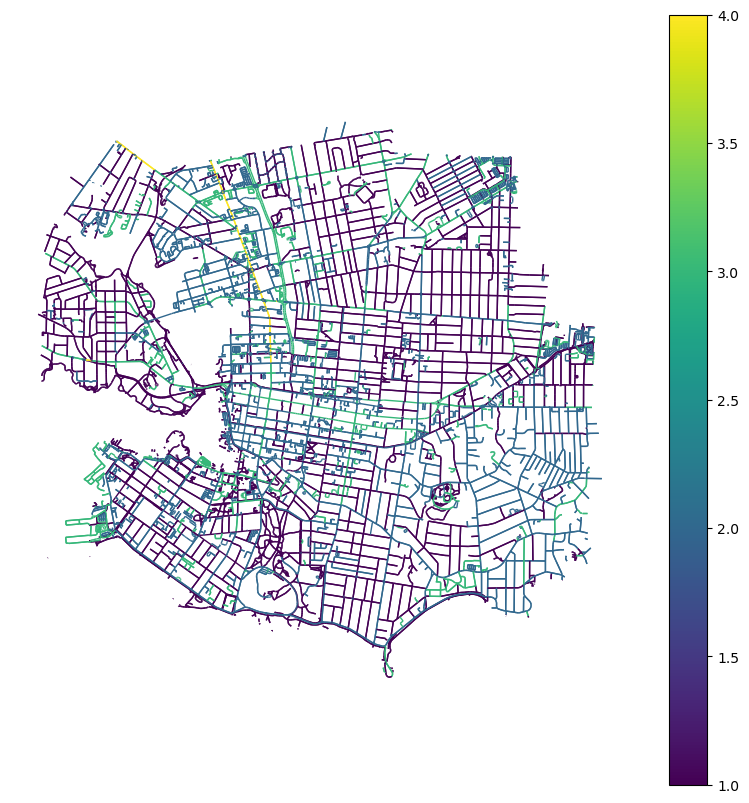

In [39]:
fig1, ax1 = plt.subplots(figsize=(10,10))

all_lts_small[(all_lts_small['lts']<=4) & (all_lts_small['lts']!=0)].plot(
    ax=ax1,
    column="lts",
    linewidth=1,
    #cmap=cmap,
    legend=True)

ax1.axis("off")
plt.show()


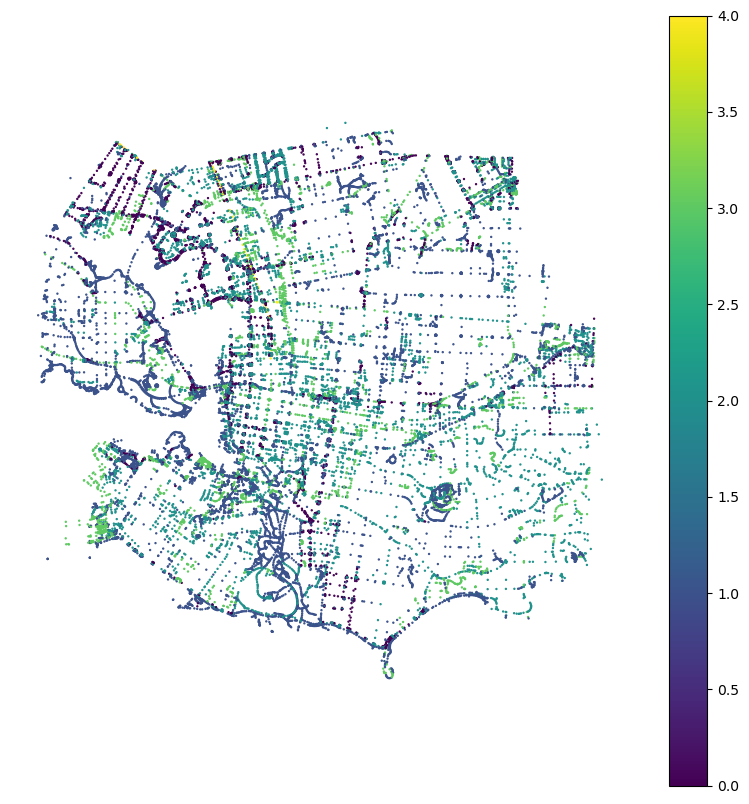

In [33]:
fig1, ax1 = plt.subplots(figsize=(10,10))

gdf_nodes.plot(
    ax=ax1,
    column="lts",
    markersize=0.5,
    linewidth=1,
    #cmap=cmap,
    legend=True)

ax1.axis("off")
plt.show()
